# Laboratory 3: Finding Hidden Objects with Contrast and Boxes

## Overview
This laboratory shows how to find and reveal objects that might be hidden in the dark. We use a real-world example: finding a mailbox in a large, dark image. We automatically find where the mailbox is, cut it out, make that small piece much brighter and clearer, and then put it back into the original image so we can see it better.

## Topics Used
* **Image Masking:** Using a "mask" to separate the object we want from the background.
* **Bounding Boxes:** Drawing a rectangle around an object to find its location (coordinates).
* **ROI (Region of Interest):** Focusing on just one small part of a larger image.
* **YUV Color Space:** A way of looking at images where "Y" is the brightness and "UV" are the colors. This is great for fixing brightness without messing up the colors.
* **CLAHE (Contrast Enhancement):** An advanced way to make dark parts of an image look bright and clear without making the already bright parts too white.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# This helper function lets us show images in our notebook
def show_image(img, title='Image'):
    if len(img.shape) == 3:
        # OpenCV uses BGR, but Matplotlib needs RGB, so we swap them here
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

### Step 1: Loading the image
First, we load the picture of the mailbox.

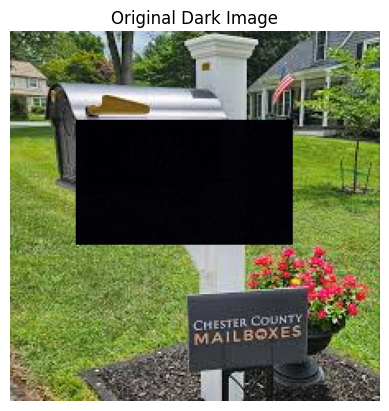

In [2]:
img = cv2.imread('MAILBOX.png')
show_image(img, 'Original Dark Image')

### Step 2: Finding the object
We turn the image to grayscale (black and white) and use a "threshold" to find only the dark parts. The `cv2.findNonZero` function then gives us the exact points where the object is.

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# We look for pixels that are quite dark (below 25) and mark them
_, mask = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY_INV)
coords = cv2.findNonZero(mask)

### Step 3: Drawing a box and cutting it out
We find the best rectangle that fits around all our points (`boundingRect`). Then we "slice" the image to get just that part (this is called the ROI - Region of Interest).

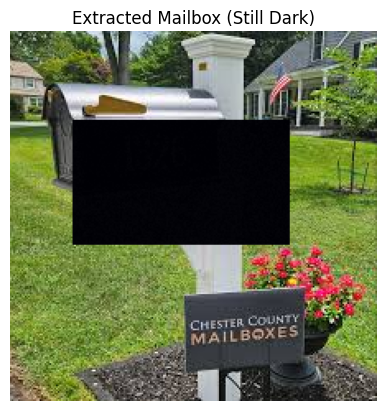

In [4]:
x, y, w, h = cv2.boundingRect(coords)
roi = img[y:y+h, x:x+w]
show_image(roi, 'Extracted Mailbox (Still Dark)')

### Step 4: Making it bright and clear
We use the YUV color space so we can fix just the brightness (`Y`). We use **CLAHE**, which is like a smart "brightness" filter that keeps details sharp.

In [5]:
yuv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2YUV)
# createCLAHE helps us boost contrast locally
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
yuv_roi[:, :, 0] = clahe.apply(yuv_roi[:, :, 0])

### Step 5: Putting it all together
We turn the small piece back to normal colors (BGR) and paste it back into the original image.

In [6]:
enhanced_roi = cv2.cvtColor(yuv_roi, cv2.COLOR_YUV2BGR)
final_img = img.copy()
final_img[y:y+h, x:x+w] = enhanced_roi

### Step 6: Saving the result
Finally, we show the revealed mailbox and save it as a file.

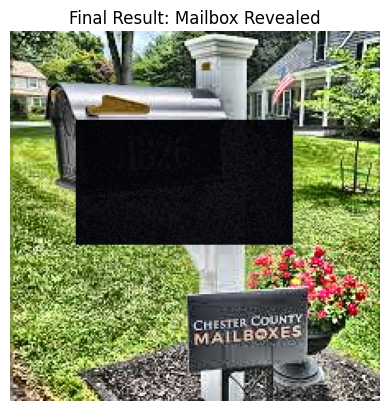

True

In [7]:
show_image(final_img, 'Final Result: Mailbox Revealed')
cv2.imwrite('mailbox_revealed.png', final_img)